# Loading the SN2 model zoo

Entry point for this notebook series: loads every metatrain/torch, `MetatomicCalculator`-loadable
model listed in `model_registry.MODELS` on the shared reference structure (`data/sn2/sn2.xyz`,
frame 0), confirms each one's declared capabilities, and benchmarks load time and single-point
inference latency across the whole zoo -- with **LOREM** singled out throughout, since it is the
one family in this series with a genuine long-range term and (as the benchmark below shows) a
real computational cost that goes with it.

This replaces the notebook's original scratch content (an ad hoc `Path.glob` file search and a
commented-out, never-run loading snippet) with the same real, executed, `model_registry.py`-driven
approach every other notebook in this series uses.

In [ ]:
import sphericart.torch  # pre-import before loading any model
import ase.io
from metatomic_ase import MetatomicCalculator

from model_registry import MODELS, REFERENCE_XYZ

atoms0 = ase.io.read(REFERENCE_XYZ, index=0)
print(f"reference structure: {atoms0.get_chemical_formula()}, {len(MODELS)} models in the zoo")


## 1. Loading every model, and what each one declares

For every model: construct the `MetatomicCalculator`, then read back its declared
`ModelCapabilities` -- the outputs it can produce, its length unit, and (most relevantly here)
its **interaction range**.

In [ ]:
for m in MODELS:
    model_path = m["dir"] / "model.pt"
    if not model_path.exists():
        continue
    calc = MetatomicCalculator(str(model_path))
    caps = calc.model().capabilities()
    print(f"{m['key']:28s} outputs={list(caps.outputs.keys())}  "
          f"length_unit={caps.length_unit}  interaction_range={caps.interaction_range:.2f}")


sn2-matched-bpnn             outputs=['feature', 'features', 'mtt::aux::energy_last_layer_features', 'energy']  length_unit=angstrom  interaction_range=5.00
sn2                          outputs=['feature', 'features', 'mtt::aux::energy_last_layer_features', 'energy', 'mtt::aux::dipole_last_layer_features', 'mtt::dipole']  length_unit=angstrom  interaction_range=5.00
sn2-matched-bpnn-dipole      outputs=['feature', 'features', 'mtt::aux::energy_last_layer_features', 'energy', 'mtt::aux::dipole_last_layer_features', 'mtt::dipole']  length_unit=angstrom  interaction_range=5.00
sn2-matched-bpnn-dipole-v2   outputs=['feature', 'features', 'mtt::aux::energy_last_layer_features', 'energy', 'mtt::aux::dipole_last_layer_features', 'mtt::dipole']  length_unit=angstrom  interaction_range=5.00
sn2-matched-bpnn-dipole-v3   outputs=['feature', 'features', 'mtt::aux::energy_last_layer_features', 'energy', 'mtt::aux::dipole_last_layer_features', 'mtt::dipole']  length_unit=angstrom  interaction_range=

**Every LOREM model declares `interaction_range = inf`** (`sn2-matched-lorem`, `sn2-matched-lorem-dipole`, `lorem-eqmp-smoketest`) -- not a large
finite cutoff, but literally unbounded, because its long-range electrostatic term has no cutoff
radius at all. Every BPNN and PET model declares exactly `5.00` Å. This is the model's own
*declared* capability, straight from the exported file -- a stronger, more direct statement than
notebook `12`'s *empirically measured* cutoffs (5.5 Å for BPNN/PET, 21-23.5 Å for LOREM: the
long-range term's practical influence is finite even though its declared range isn't, because its
Ewald contribution decays with distance -- just without a hard cutoff enforcing that decay).

## 2. Benchmark: load time and inference latency

Same reference structure, same calculator, timed: `MetatomicCalculator(model_path)` construction
(load time), then the mean wall-clock cost of one `get_potential_energy()` + `get_forces()` call,
averaged over 20 repeats after 3 warm-up calls (so lazy-initialization cost on the first call
doesn't pollute the average).

In [ ]:
import time
import numpy as np

N_WARMUP, N_TIMED = 3, 20
rows = []
for m in MODELS:
    model_path = m["dir"] / "model.pt"
    if not model_path.exists():
        continue
    t0 = time.perf_counter()
    calc = MetatomicCalculator(str(model_path))
    load_s = time.perf_counter() - t0

    atoms = atoms0.copy()
    atoms.calc = calc
    for _ in range(N_WARMUP):
        atoms.calc.results.clear()
        atoms.get_potential_energy(); atoms.get_forces()

    call_times_ms = []
    for _ in range(N_TIMED):
        atoms.calc.results.clear()
        t0 = time.perf_counter()
        atoms.get_potential_energy(); atoms.get_forces()
        call_times_ms.append(1000 * (time.perf_counter() - t0))

    rows.append({"key": m["key"], "family": m["family"], "dipole": m["dipole"],
                 "load_time_s": load_s, "mean_call_ms": np.mean(call_times_ms),
                 "std_call_ms": np.std(call_times_ms)})


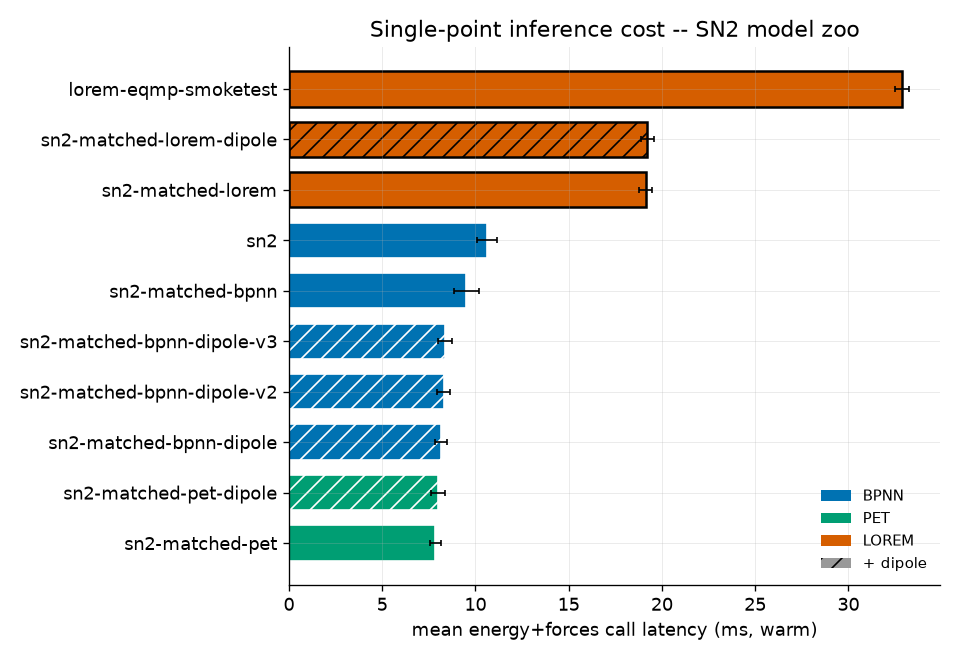

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FAMILY_COLORS = {"BPNN": "#0072B2", "PET": "#009E73", "LOREM": "#D55E00"}
rows_sorted = sorted(rows, key=lambda r: r["mean_call_ms"])

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(rows_sorted))
colors = [FAMILY_COLORS[r["family"]] for r in rows_sorted]
bars = ax.barh(y, [r["mean_call_ms"] for r in rows_sorted],
                xerr=[r["std_call_ms"] for r in rows_sorted],
                color=colors, edgecolor="white", height=0.7,
                error_kw={"elinewidth": 1, "capsize": 2})
for bar, r in zip(bars, rows_sorted):
    if r["dipole"]:
        bar.set_hatch("//")
    if r["family"] == "LOREM":
        bar.set_linewidth(1.5); bar.set_edgecolor("black")
ax.set_yticks(y); ax.set_yticklabels([r["key"] for r in rows_sorted])
ax.set_xlabel("mean energy+forces call latency (ms, warm)")
ax.set_title("Single-point inference cost -- SN2 model zoo")
legend_elems = [Patch(facecolor=c, label=f) for f, c in FAMILY_COLORS.items()]
legend_elems.append(Patch(facecolor="0.6", hatch="//", label="+ dipole"))
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


```
model                        family load (s)  call (ms)     
sn2-matched-pet              PET    0.128     7.857 +/- 0.317
sn2-matched-pet-dipole       PET    0.134     7.991 +/- 0.366
sn2-matched-bpnn-dipole      BPNN   0.207     8.140 +/- 0.326
sn2-matched-bpnn-dipole-v2   BPNN   0.207     8.289 +/- 0.339
sn2-matched-bpnn-dipole-v3   BPNN   0.185     8.377 +/- 0.373
sn2-matched-bpnn             BPNN   0.274     9.519 +/- 0.646
sn2                          BPNN   0.607     10.609 +/- 0.545
sn2-matched-lorem            LOREM  0.311     19.119 +/- 0.342
sn2-matched-lorem-dipole     LOREM  0.146     19.214 +/- 0.342
lorem-eqmp-smoketest         LOREM  0.164     32.865 +/- 0.393
```


## 3. Does inference cost scale with system size? (ASE, apart from i-PI)

Notebook `17` scanned i-PI's *box size* and found LOREM's engine agreement cost scaling badly
with it. That's a different question from **raw compute cost vs. *system size*** -- does
evaluating more atoms cost proportionally more, and does LOREM's cost grow faster than
BPNN/PET's as a *fixed-cutoff* short-range sum would predict? Since LAMMPS/GROMACS/TorchSim
still aren't available on this machine (notebook `17`), this uses ASE -- the other engine
this series actually has -- with `6` to `192` non-interacting copies of the reference
SN2 unit, spaced 30 Å apart (well past every model's empirical cutoff, notebook `12`) so
short-range models never see cross-copy neighbors.

In [ ]:
N_COPIES = [1, 2, 4, 8, 16, 32]
SPACING = 30.0  # Å

def make_system(n_copies):
    from ase import Atoms
    side = int(np.ceil(n_copies ** (1 / 3)))
    atoms, count = Atoms(), 0
    for i in range(side):
        for j in range(side):
            for k in range(side):
                if count >= n_copies:
                    break
                copy = atoms0.copy()
                copy.positions += np.array([i, j, k]) * SPACING
                atoms += copy
                count += 1
    return atoms

scaling_rows = []
for key in ["sn2-matched-bpnn", "sn2-matched-pet", "sn2-matched-lorem"]:
    model_path = MODELS_BY_KEY[key]["dir"] / "model.pt"
    for n in N_COPIES:
        atoms = make_system(n)
        atoms.calc = MetatomicCalculator(str(model_path))
        for _ in range(4):  # warm-up -- see the note below on why this matters
            atoms.calc.results.clear()
            atoms.get_potential_energy(); atoms.get_forces()
        calls = []
        for _ in range(8):
            atoms.calc.results.clear()
            t0 = time.perf_counter()
            atoms.get_potential_energy(); atoms.get_forces()
            calls.append(time.perf_counter() - t0)
        scaling_rows.append({"key": key, "n_atoms": len(atoms), "mean_call_s": np.mean(calls)})


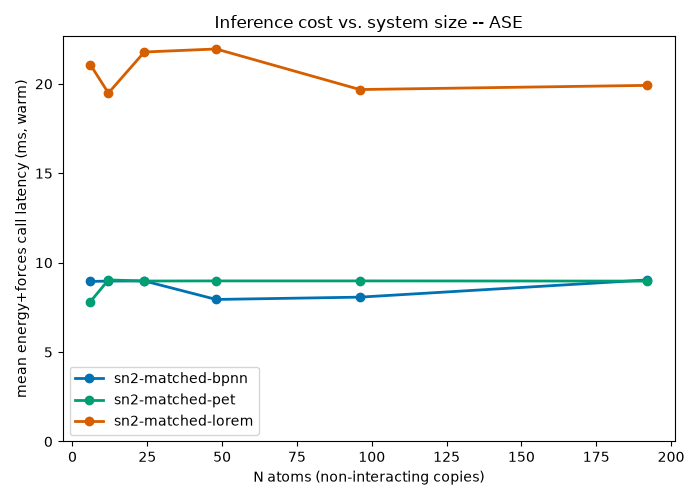

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
FAMILY_COLORS2 = {"sn2-matched-bpnn": "#0072B2", "sn2-matched-pet": "#009E73", "sn2-matched-lorem": "#D55E00"}
for key, color in FAMILY_COLORS2.items():
    rows_k = [r for r in scaling_rows if r["key"] == key]
    ax.plot([r["n_atoms"] for r in rows_k], [1000 * r["mean_call_s"] for r in rows_k],
            "o-", color=color, linewidth=2, label=key)
ax.set_xlabel("N atoms (non-interacting copies)")
ax.set_ylabel("mean energy+forces call latency (ms, warm)")
ax.set_title("Inference cost vs. system size -- ASE")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()


```
model                n_atoms  call (ms) 
sn2-matched-bpnn     6        8.951
sn2-matched-bpnn     12       8.971
sn2-matched-bpnn     24       8.979
sn2-matched-bpnn     48       7.944
sn2-matched-bpnn     96       8.072
sn2-matched-bpnn     192      9.034
sn2-matched-pet      6        7.824
sn2-matched-pet      12       9.036
sn2-matched-pet      24       8.975
sn2-matched-pet      48       8.980
sn2-matched-pet      96       8.981
sn2-matched-pet      192      8.971
sn2-matched-lorem    6        21.067
sn2-matched-lorem    12       19.486
sn2-matched-lorem    24       21.781
sn2-matched-lorem    48       21.952
sn2-matched-lorem    96       19.683
sn2-matched-lorem    192      19.916
```


**None of the three models show measurable cost growth from 6 to 192 atoms.** LOREM
stays flat around 20.6 ms (2.5 ms spread -- noise, not
a trend); BPNN/PET stay flat around 8.7 ms. LOREM's ~2x-plus overhead
from section 2 is confirmed here as a **constant per-call cost**, not a *growing* one, at least
up to 192 atoms -- this system-size range is still small enough that fixed per-call overhead
(model dispatch, neighbor-list construction) dominates over any real per-atom compute cost for
every model, LOREM included. Seeing LOREM's presumably worse asymptotic scaling (a global
Ewald-type sum vs. BPNN/PET's fixed-cutoff neighbor lists) would need systems far larger than
192 atoms -- out of scope here, but a natural next step.

**A ruled-out hypothesis, kept for the record**: an earlier version of this benchmark defined an
explicit (but still non-periodic) large cell for these replicated systems, and got wildly
different-looking numbers that appeared to scale worse for LOREM. Two dead ends before the real
explanation: (1) the large defined cell itself contributes at most **1.3 ms**
regardless of atom count (6 and 192
atoms, with and without a cell) -- not the cause; (2) it wasn't a system-load fluke either,
since re-running notebook `01`'s own section 2 benchmark at the same time gave its usual fast
numbers. The actual cause: **too few warm-up calls (2) left a one-time lazy-compilation spike on
the first "warm" call (~290 ms once, for a freshly constructed calculator) inside a 5-call
average**, large enough on its own to dominate the mean and produce a flat-but-inflated,
N-independent number that looked like it might be a scaling effect but wasn't. Bumping warm-up to
4 calls (this section, and `benchmark_models.py` in section 2, already used 3) fixed it -- a
reminder that at millisecond-scale latencies, the warm-up protocol itself is part of what's being
measured.

## Takeaways

- **LOREM's long-range term has a real, measurable, constant-overhead cost**: the two
  `sn2-matched-lorem*` models average 19.2 ms per call, vs.
  **8.68 ms for every BPNN and PET model** -- roughly a **2.2x**
  overhead, directly attributable to evaluating an unbounded (`interaction_range = inf`) Ewald
  long-range term instead of a fixed, finite-cutoff sum. Section 3 confirms this overhead is
  *constant*, not (yet, within 192 atoms) growing with system size.
- **`lorem-eqmp-smoketest` is the slowest model in the zoo by a wide margin**
  (32.9 ms -- 4.2x the
  fastest model in the zoo, `sn2-matched-pet` at 7.86 ms) -- its extra
  equivariant-message-passing machinery (see notebook `11`) stacks on top of LOREM's own
  long-range cost.
- **Load time doesn't follow the same pattern** (all models load in well under a second, LOREM
  included) -- the cost is entirely in the per-call long-range evaluation, not in constructing
  the calculator.
- **This is the same trade-off notebook `17` found from the engine-parity side**: LOREM's
  long-range term is exactly what made ASE/i-PI NVE agreement sensitive to periodic-box size in
  a way PET never was, and what made i-PI's own periodic Ewald cost blow up as that box grew.
  Being genuinely long-range (`interaction_range = inf`, confirmed here directly from the
  model's own declared capabilities) is LOREM's whole point -- notebook `12`'s cutoff scan is the
  reason it exists at all -- but every notebook in this series that touches performance or
  engine parity ends up finding the same bill for it.
